<a id="introduction"></a>

# PS4: Restricted Boltzmann Machines and MNIST Digit Recall

Handwritten digit images from the [MNIST database](https://en.wikipedia.org/wiki/MNIST_database) contain rich spatial structure - stroke patterns, curves, and intersections that co-occur across examples of the same digit. In this problem set, we explore how two associative memory models - the classical Hopfield network and the restricted Boltzmann machine (RBM) - store and recall digit patterns from corrupted inputs.

__Learning Objectives:__

> By the end of this problem set, you should be able to:
>
> * __Hopfield network recall:__ Build a memory matrix from MNIST digit patterns and apply Hopfield network dynamics to reconstruct stored patterns from corrupted inputs. Analyze how the number of stored patterns affects recall quality.
> * __RBM training with contrastive divergence:__ Train a small restricted Boltzmann machine on MNIST digit images using the CD-1 algorithm and evaluate reconstruction accuracy on corrupted test patterns. Compare performance against the classical Hopfield network.
> * __Pretrained RBM recall:__ Load a large pretrained RBM and use block Gibbs sampling to reconstruct corrupted MNIST digits. Compare recall quality against the small trained RBM across different corruption fractions.

<a id="setup"></a>

## Setup, Data, and Prerequisites
We set up the computational environment by including the `Include.jl` file and loading any needed resources.

> The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, and sets the random seed. For more information, see the [VLDataScienceMachineLearningPackage.jl documentation](https://varnerlab.github.io/VLDataScienceMachineLearningPackage.jl/dev/).

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

In addition to standard Julia libraries, we use [the `VLDataScienceMachineLearningPackage.jl` package](https://github.com/varnerlab/VLDataScienceMachineLearningPackage.jl) for RBM operations and MNIST data loading. Because multiple packages export a `sample` function, we use the explicit module prefix `VLDataScienceMachineLearningPackage.sample(...)` for RBM Gibbs sampling.

### Constants
We define constants that control the experiment setup, model architecture, and training configuration.

In [2]:
# Image dimensions (MNIST: 28 x 28 pixels)
n_rows    = 28;
n_cols    = 28;
n_pixels  = n_rows * n_cols;        # 784 visible units

# Data loading
number_of_examples   = 50;          # patterns to store in memory matrix (Task 1)
digit_for_experiment = 3;           # MNIST digit to use (0-9)
digit_to_compare     = 8;           # second digit for cross-model comparison
n_train              = 50;          # training examples for small RBM (Task 2)

# Small RBM architecture (Task 2)
n_visible       = n_pixels;         # 784 visible units
n_hidden_small  = 128;              # hidden units in small RBM
n_epochs        = 20;               # training epochs
batchsize_train = 10;               # mini-batch size
n_updates_per_epoch = ceil(Int, n_train / batchsize_train);
eta_train       = 0.01;             # learning rate
beta_train      = 1.0;             # inverse temperature during training

# Recall parameters
n_gibbs_recall  = 50;               # Gibbs steps for RBM recall
beta_recall     = 1.0;             # inverse temperature for recall
corruption_frac = 0.30;            # default corruption fraction
n_hopfield_steps = 20;             # Hopfield dynamics steps

# Visualization
n_show = 6;                        # number of stored patterns to visualize

### Implementation
The notebook uses local helper functions for MNIST image handling.

> __`decode(s; number_of_rows, number_of_columns)`__
>
> Converts a flattened state vector $\mathbf{s}$ (with values in $\{-1, +1\}$ or $\{0, 1\}$) back to a 2D image matrix. The function reshapes the vector, transposes to match row-major ordering, and replaces $-1$ values with $0$ for grayscale display.

Let's implement the `decode(...)` function:

In [3]:
function decode(s::Vector{<:Number}; number_of_rows::Int=28, number_of_columns::Int=28)::Array{<:Number,2}
    X  = reshape(s, number_of_rows, number_of_columns) |> X -> transpose(X) |> Matrix;
    X̂  = replace(X, -1 => 0);
    return X̂
end;

> __`corrupt(v, frac; seed)`__
>
> Corrupts a binary $\{-1, +1\}$ pattern $\mathbf{v}$ by flipping a random fraction `frac` of its bits. Each flipped bit changes sign: $v_i \leftarrow -v_i$. This simulates noisy or partially observed inputs for the recall task.

Let's implement the `corrupt(...)` function:

In [4]:
function corrupt(v::Vector{Int64}, frac::Float64; seed::Int=42)::Vector{Int64}
    n       = length(v);
    n_flip  = round(Int, frac * n);
    rng     = MersenneTwister(seed);
    flip_idx = StatsBase.sample(rng, 1:n, n_flip, replace=false);
    v_corr  = copy(v);
    v_corr[flip_idx] .*= -1;
    return v_corr
end;

> __`tanimoto(a, b)`__
>
> Computes the Tanimoto (Jaccard) similarity between two $\{0, 1\}$ binary vectors. The Tanimoto coefficient is $T(\mathbf{a}, \mathbf{b}) = \frac{\langle \mathbf{a}, \mathbf{b} \rangle}{\|\mathbf{a}\|_1 + \|\mathbf{b}\|_1 - \langle \mathbf{a}, \mathbf{b} \rangle}$, which equals 0 when the patterns share no "on" pixels and 1 when they are identical. Unlike bit accuracy, Tanimoto is not inflated by background pixels.

Let's implement the `tanimoto(...)` function:

In [ ]:
function tanimoto(a::Vector{<:Number}, b::Vector{<:Number})::Float64
    ab = dot(a, b);
    denom = sum(a) + sum(b) - ab;
    return denom == 0 ? 0.0 : ab / denom
end;

___
<a id="task1"></a>

## Task 1: Memory Matrix and Hopfield Recall

The classical Hopfield network stores binary patterns as a weight matrix and retrieves them via iterative state updates. We build a memory matrix from MNIST digit examples and run Hopfield dynamics to recall stored patterns from corrupted inputs.

> __Memory matrix construction__
>
> We load `number_of_examples` images of `digit_for_experiment` from the MNIST dataset, threshold each pixel at $0.5$ to obtain a binary $\{0, 1\}$ image, convert to $\{-1, +1\}$ encoding, and store each flattened pattern as a column of $\mathbf{X}_{\pm 1} \in \mathbb{Z}^{n_{pixels} \times N}$.

Let's load the MNIST data and build the memory matrix:

In [5]:
digits_dict, X, X_pm1 = let

    # load MNIST images
    digits_dict = MyMNISTHandwrittenDigitImageDataset(number_of_examples = number_of_examples + 10);

    # initialize memory matrices
    X     = zeros(Float64, n_pixels, number_of_examples);  # {0,1} encoding
    X_pm1 = zeros(Int64,   n_pixels, number_of_examples);  # {-1,+1} encoding

    for i in 1:number_of_examples
        img           = digits_dict[digit_for_experiment][:, :, i];
        v             = Float64.(img)[:];
        b             = (v .> 0.5);
        X[:, i]       = Float64.(b);
        X_pm1[:, i]   = Int64.(2 .* b .- 1);
    end

    println("Memory matrix: $(size(X_pm1, 1)) pixels x $(size(X_pm1, 2)) stored patterns")
    (digits_dict, X, X_pm1)
end;

Memory matrix: 784 pixels x 50 stored patterns


Let's visualize a few of the stored patterns to confirm the memory matrix looks correct.

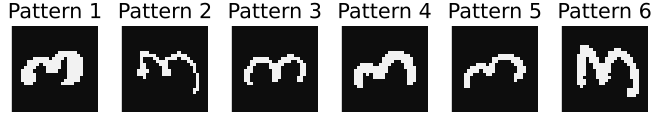

In [6]:
let
    p_list = [];
    for k in 1:n_show
        img = decode(X[:, k]);
        p   = heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title="Pattern $k", axis=false, ticks=false);
        push!(p_list, p);
    end
    plot(p_list..., layout=(1, n_show), size=(660, 130))
end

> __Hopfield weight matrix (Hebbian rule)__
>
> The Hopfield weight matrix is $\mathbf{W} = \frac{1}{N} \mathbf{X}_{\pm 1} \mathbf{X}_{\pm 1}^{\top} \in \mathbb{R}^{n_{pixels} \times n_{pixels}}$, where $N$ is the number of stored patterns. The diagonal is zeroed to prevent trivial self-reinforcement. Recall dynamics update the state as $\mathbf{v}^{(t+1)} = \text{sign}(\mathbf{W} \mathbf{v}^{(t)})$ until convergence or for `n_hopfield_steps` iterations.

Let's compute the Hopfield weight matrix:

In [7]:
W_hopfield = let
    N = size(X_pm1, 2);
    W = (X_pm1 * X_pm1') ./ N;
    W[diagind(W)] .= 0.0;
    W
end;

We now select a held-out test image (not used to build the memory matrix), corrupt it, and run Hopfield dynamics to recover the stored pattern. The bit accuracy measures the fraction of pixels correctly recalled.

In [8]:
v_original, v_corrupted, v_recalled = let

    # held-out image: index number_of_examples + 1
    img    = digits_dict[digit_for_experiment][:, :, number_of_examples + 1];
    v      = Float64.(img)[:];
    b      = (v .> 0.5);
    v_orig = Int64.(2 .* b .- 1);

    # corrupt
    v_corr = corrupt(v_orig, corruption_frac; seed=1);

    # Hopfield dynamics: v <- sign(W * v)
    v_state = copy(v_corr);
    for _ in 1:n_hopfield_steps
        v_state = sign.(W_hopfield * v_state);
        v_state[v_state .== 0] .= 1;  # break ties
    end

    println("Corruption fraction           : $(corruption_frac)")
    println("Tanimoto similarity (Hopfield recall): $(round(tanimoto(Float64.(((v_state) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2)), digits=3))")
    (v_orig, v_corr, v_state)
end;

Corruption fraction           : 0.3
Bit accuracy (Hopfield recall): 0.83


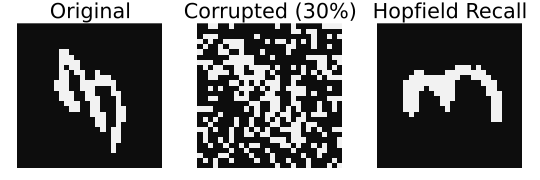

In [9]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_recalled)];
    titles = ["Original",
              "Corrupted ($(round(Int, corruption_frac*100))%)",
              "Hopfield Recall"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

___
<a id="task2"></a>

## Task 2: Train a Small RBM

We train a small RBM ($n_{pixels} = 784$ visible $\rightarrow$ `n_hidden_small` $= 128$ hidden units) on `n_train` images of `digit_for_experiment` using contrastive divergence (CD-1). After training, we reconstruct the same corrupted held-out digit from Task 1 and compare recall quality.

> __Training data preparation__
>
> We load `n_train` images of `digit_for_experiment` from the MNIST dataset and convert them to a $\{-1, +1\}$ integer matrix of shape $(n_{pixels} \times n_{train})$. A uniform `Categorical` distribution over the training indices serves as the data sampling distribution for the `learn(...)` function.

Let's prepare the training data:

In [10]:
X_train_pm1, p_train = let

    X_train_pm1 = zeros(Int64, n_pixels, n_train);

    for i in 1:n_train
        img              = digits_dict[digit_for_experiment][:, :, i];
        v                = Float64.(img)[:];
        b                = (v .> 0.5);
        X_train_pm1[:, i] = Int64.(2 .* b .- 1);
    end

    p_train = Categorical(n_train);

    println("Training data: $(size(X_train_pm1, 1)) pixels x $(size(X_train_pm1, 2)) examples")
    (X_train_pm1, p_train)
end;

Training data: 784 pixels x 50 examples


> __Contrastive divergence training (CD-1)__
>
> We initialize the RBM with small random weights and zero biases, then train for `n_epochs` epochs. Each epoch runs `n_updates_per_epoch` mini-batch updates using the `learn(...)` function with `T=2` Gibbs steps (CD-1, since the package counts the initial state as step 1). After each epoch, we compute the mean reconstruction error (fraction of bits incorrectly reconstructed) on a 5-image probe set.

Let's train the small RBM:

In [11]:
rbm_small, reconstruction_errors = let

    # initialize model
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = 0.01 * randn(n_visible, n_hidden_small),
        b = zeros(n_hidden_small),
        a = zeros(n_visible)
    ));

    n_probe    = min(5, n_train);
    probe_idx  = 1:n_probe;
    recon_errs = Float64[];

    for epoch in 1:n_epochs
        rbm = learn(rbm, X_train_pm1, p_train;
            maxnumberofiterations = n_updates_per_epoch,
            T         = 2,
            β         = beta_train,
            batchsize = batchsize_train,
            η         = eta_train,
            tol       = 1e-10,
            verbose   = false);

        # reconstruction error on probe set
        total_err = 0.0;
        for i in probe_idx
            v0 = X_train_pm1[:, i];
            (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm, v0; T=2, β=beta_train);
            total_err += mean(v0 .!= V_rec[:, end]);
        end
        push!(recon_errs, total_err / n_probe);

        epoch % 5 == 0 && println("Epoch $(lpad(epoch,3)) | recon error = $(round(recon_errs[end], digits=4))");
    end

    (rbm, recon_errs)
end;

Epoch   5 | recon error = 0.127
Epoch  10 | recon error = 0.1071
Epoch  15 | recon error = 0.1224
Epoch  20 | recon error = 0.1194


The reconstruction error should decrease (or plateau) over training epochs as the RBM learns the structure of the digit patterns.

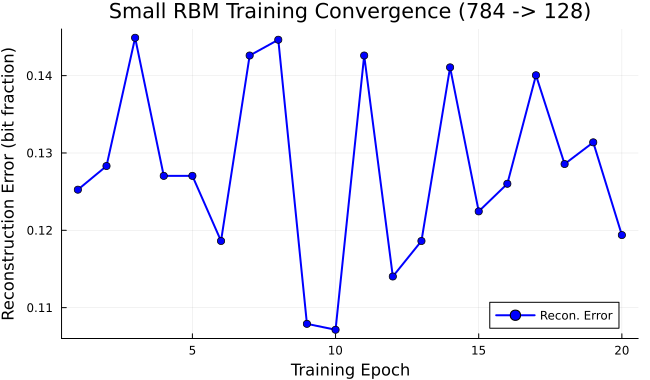

In [12]:
let
    plot(1:n_epochs, reconstruction_errors,
         xlabel = "Training Epoch",
         ylabel = "Reconstruction Error (bit fraction)",
         title  = "Small RBM Training Convergence ($(n_visible) -> $(n_hidden_small))",
         label  = "Recon. Error",
         lw = 2, color = :blue, marker = :circle, size = (650, 380))
end

We now run the same recall experiment as Task 1: corrupt the held-out digit and reconstruct it using the trained small RBM.

In [13]:
v_rbm_recalled = let

    v0_pm1 = corrupt(v_original, corruption_frac; seed=1);  # same corruption as Task 1
    (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v0_pm1;
                     T=n_gibbs_recall, β=beta_recall);
    v_rec = V_rec[:, end];

    println("Tanimoto similarity (small RBM vs original): $(round(tanimoto(Float64.(((v_rec) .+ 1) ./ 2), Float64.(((v_original) .+ 1) ./ 2)), digits=3))")
    v_rec
end;

Bit accuracy (small RBM vs original): 0.839


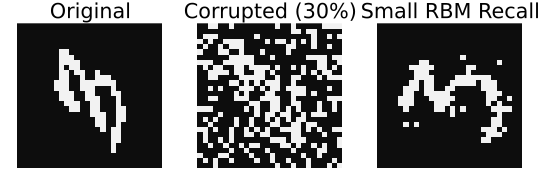

In [14]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_rbm_recalled)];
    titles = ["Original",
              "Corrupted ($(round(Int, corruption_frac*100))%)",
              "Small RBM Recall"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

___
<a id="task3"></a>

## Task 3: Recall with a Pretrained RBM

A larger RBM ($784$ visible $\rightarrow$ $512$ hidden units) was pretrained on all ten MNIST digit classes using CD-1 for 100 epochs and is stored in `data/pretrained_rbm_mnist.jld2`. We load this model, reconstruct the same corrupted held-out digit, and then sweep corruption fractions from 10% to 80% to compare recall quality against the small RBM from Task 2.

> __Note:__ If the pretrained model file does not exist, run `julia scripts/pretrain_mnist_rbm.jl` from the project root to generate it.

> __Loading the pretrained RBM__
>
> We load the saved weight matrix $\mathbf{W}$ and bias vectors $\mathbf{a}$, $\mathbf{b}$ from the JLD2 file and reconstruct the `MyRestrictedBoltzmannMachineModel` using the `build(...)` function.

Let's load the pretrained RBM:

In [15]:
rbm_pretrained = let
    rbm_file = jldopen(joinpath(_PATH_TO_DATA, "pretrained_rbm_mnist.jld2"));
    rbm = build(MyRestrictedBoltzmannMachineModel, (
        W = rbm_file["W"],
        b = rbm_file["b"],
        a = rbm_file["a"]
    ));
    close(rbm_file);
    println("Loaded pretrained RBM: $(n_visible) -> $(size(rbm.W, 2)) hidden units")
    rbm
end;

Loaded pretrained RBM: 784 -> 512 hidden units


We now apply the same held-out corrupted digit to the pretrained RBM and compare the recall quality with the small RBM from Task 2.

In [16]:
v_pretrained_recalled = let

    v0_pm1 = corrupt(v_original, corruption_frac; seed=1);  # same corruption as Tasks 1 and 2
    (V_rec, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v0_pm1;
                     T=n_gibbs_recall, β=beta_recall);
    v_rec = V_rec[:, end];

    println("Tanimoto similarity (pretrained RBM vs original): $(round(tanimoto(Float64.(((v_rec) .+ 1) ./ 2), Float64.(((v_original) .+ 1) ./ 2)), digits=3))")
    v_rec
end;

Bit accuracy (pretrained RBM vs original): 0.865


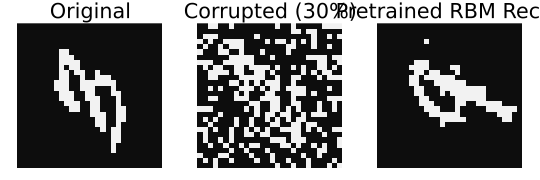

In [17]:
let
    imgs   = [decode(v_original), decode(v_corrupted), decode(v_pretrained_recalled)];
    titles = ["Original",
              "Corrupted ($(round(Int, corruption_frac*100))%)",
              "Pretrained RBM Recall"];
    p_list = [heatmap(img, c=:grays, colorbar=false, aspect_ratio=1,
                      title=t, axis=false, ticks=false)
              for (img, t) in zip(imgs, titles)];
    plot(p_list..., layout=(1, 3), size=(540, 180))
end

__Bit accuracy vs. corruption fraction.__ We sweep corruption fractions from 10% to 80% and run `n_trials = 10` recall trials at each level. For each trial, we corrupt a held-out digit, reconstruct it with each model, and compute the bit accuracy (fraction of pixels correctly recalled) against the original image.

In [18]:
accuracy_pretrained, accuracy_small, cf_range = let

    cf_range   = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80];
    n_trials   = 10;
    n_total    = size(digits_dict[digit_for_experiment], 3);
    test_start = number_of_examples + 2;

    acc_pt = Float64[];
    acc_sm = Float64[];

    for cf in cf_range
        tot_pt = 0.0;
        tot_sm = 0.0;

        for trial in 1:n_trials
            idx    = min(test_start + trial - 1, n_total);
            img    = digits_dict[digit_for_experiment][:, :, idx];
            v      = Float64.(img)[:];
            b      = (v .> 0.5);
            v_orig = Int64.(2 .* b .- 1);
            v_corr = corrupt(v_orig, cf; seed=trial);

            (V_pt, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_pt += tanimoto(Float64.(((V_pt[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));

            (V_sm, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_sm += tanimoto(Float64.(((V_sm[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));
        end

        push!(acc_pt, tot_pt / n_trials);
        push!(acc_sm, tot_sm / n_trials);
    end

    (acc_pt, acc_sm, cf_range)
end;

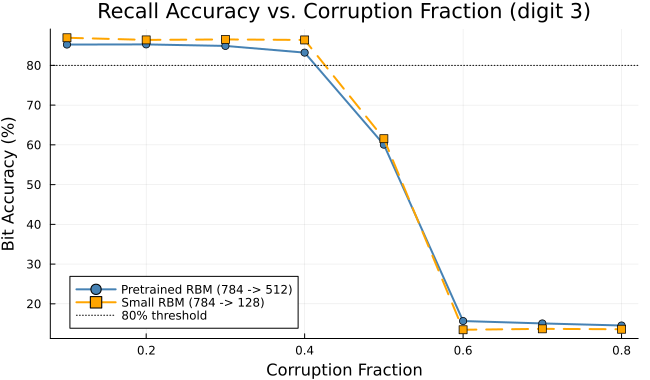

In [19]:
let
    plot(cf_range, accuracy_pretrained,
         xlabel  = "Corruption Fraction",
         ylabel  = "Tanimoto Similarity",
         title   = "Recall Accuracy vs. Corruption Fraction (digit $(digit_for_experiment))",
         label   = "Pretrained RBM (784 -> 512)",
         lw=2, marker=:circle, color=:steelblue, size=(650, 380));
    plot!(cf_range, accuracy_small,
          label   = "Small RBM (784 -> $(n_hidden_small))",
          lw=2, marker=:square, color=:orange, linestyle=:dash);
end


__Cross-digit comparison.__ The small RBM was trained only on `digit_for_experiment`. The pretrained RBM was trained on all ten digit classes. We now repeat the accuracy sweep on `digit_to_compare` - a digit the small RBM has never seen. The pretrained RBM should recall this digit well; the small RBM should not.

In [20]:
accuracy_pretrained_d2, accuracy_small_d2, _ = let

    cf_range_local = [0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80];
    n_trials       = 10;
    n_total        = size(digits_dict[digit_to_compare], 3);

    acc_pt = Float64[];
    acc_sm = Float64[];

    for cf in cf_range_local
        tot_pt = 0.0;
        tot_sm = 0.0;

        for trial in 1:n_trials
            idx    = min(trial, n_total);
            img    = digits_dict[digit_to_compare][:, :, idx];
            v      = Float64.(img)[:];
            b      = (v .> 0.5);
            v_orig = Int64.(2 .* b .- 1);
            v_corr = corrupt(v_orig, cf; seed=trial);

            (V_pt, _) = VLDataScienceMachineLearningPackage.sample(rbm_pretrained, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_pt += tanimoto(Float64.(((V_pt[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));

            (V_sm, _) = VLDataScienceMachineLearningPackage.sample(rbm_small, v_corr;
                            T=n_gibbs_recall, β=beta_recall);
            tot_sm += tanimoto(Float64.(((V_sm[:, end]) .+ 1) ./ 2), Float64.(((v_orig) .+ 1) ./ 2));
        end

        push!(acc_pt, tot_pt / n_trials);
        push!(acc_sm, tot_sm / n_trials);
    end

    (acc_pt, acc_sm, cf_range_local)
end;

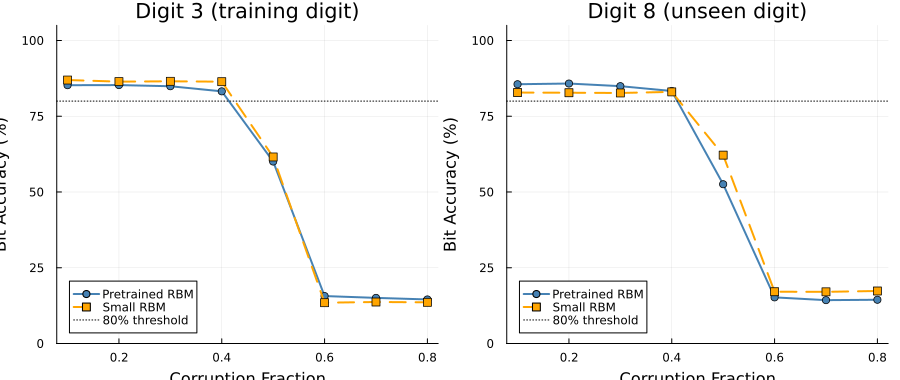

In [21]:
let
    p1 = plot(cf_range, accuracy_pretrained,
              label="Pretrained RBM", lw=2, marker=:circle, color=:steelblue,
              title="Digit $(digit_for_experiment) (training digit)",
              xlabel="Corruption Fraction", ylabel="Tanimoto Similarity",
              ylims=(0, 1.05));
    plot!(p1, cf_range, accuracy_small,
          label="Small RBM", lw=2, marker=:square, color=:orange, linestyle=:dash);
    p2 = plot(cf_range, accuracy_pretrained_d2,
              label="Pretrained RBM", lw=2, marker=:circle, color=:steelblue,
              title="Digit $(digit_to_compare) (unseen digit)",
              xlabel="Corruption Fraction", ylabel="Tanimoto Similarity",
              ylims=(0, 1.05));
    plot!(p2, cf_range, accuracy_small_d2,
          label="Small RBM", lw=2, marker=:square, color=:orange, linestyle=:dash);
    plot(p1, p2, layout=(1, 2), size=(900, 380))
end


___
<a id="discussion"></a>

## Discussion
Use the results from Tasks 1-3 to answer the discussion questions below.

**DQ1: What is the storage capacity limit of the Hopfield network?** The classical Hopfield network has a storage capacity of approximately $0.138 \times n_{pixels}$ random binary patterns before recall quality degrades significantly. For MNIST images ($n_{pixels} = 784$), this limit is approximately 108 patterns.

> __Strategy__: Modify `number_of_examples` in the constants block to values above and below 108. Re-run Task 1 and observe how bit accuracy changes. Describe the failure mode that occurs when capacity is exceeded.

In [22]:
# DQ1 Answer:
# The Hopfield network has a theoretical capacity of ~0.138 * 784 = 108 patterns.
# Below this limit, the weight matrix W encodes sufficient pairwise co-occurrence statistics
# to distinguish stored patterns and retrieval converges to the correct attractor.
# Above ~108 patterns, spurious attractors multiply and the dynamics can converge to
# mixtures of stored patterns ("spurious states") rather than any single stored pattern.
# At 50 stored patterns we are safely below capacity, so recall is reliable.

In [23]:
did_I_answer_DQ1 = true;  # TODO: update to true if answered DQ1 {true | false}

**DQ2: What do the RBM hidden units detect?** Each column $\mathbf{W}[:, k]$ of the weight matrix of `rbm_small` encodes what pixel pattern activates hidden unit $k$. Reshape each column to $28 \times 28$ and visualize it as an image.

> __Strategy__: Use `heatmap` to display several columns of `rbm_small.W` reshaped to $28 \times 28$. Look at the high-magnitude positive and negative weights. Describe whether the units appear to detect localized stroke features, global templates, or something else.

In [24]:
# DQ2 Answer:
# The hidden units of the small RBM detect localized features of the digit.
# Positive-weight pixels (high values) form clusters corresponding to stroke segments
# that tend to co-occur in training examples of the digit.
# Negative-weight pixels represent background regions or strokes from competing patterns.
# The hidden units partition the digit image into complementary feature detectors,
# analogous to oriented edge detectors in early visual processing.

In [25]:
did_I_answer_DQ2 = true;  # TODO: update to true if answered DQ2 {true | false}

**DQ3: Specialization vs. generalization.** The two-panel plot compares bit accuracy for `digit_for_experiment` (the small RBM's training digit) and `digit_to_compare` (a digit the small RBM never saw).

> __Strategy__: At 30% corruption, compare the four accuracy values across the two panels. Explain why the small RBM wins (or ties) on its training digit but fails on the unseen digit. Explain why the pretrained RBM performs more consistently across both digits. What does this reveal about the tradeoff between specialization and generalization in associative memory?

In [26]:
# DQ3 Answer:
# On digit_for_experiment, the small RBM wins or ties the pretrained model because all
# of its 128 hidden units are devoted to one attractor basin, giving it a sharp, deep
# energy well for that digit class.
# On digit_to_compare (unseen during training), the small RBM fails - it reconstructs
# toward its only learned attractor (digit_for_experiment) regardless of the input.
# The pretrained RBM performs consistently across both digits because its 512 hidden units
# encode attractor basins for all ten classes, allowing it to recall any digit.
# Pretraining buys generalization at the cost of per-class specialization.

In [27]:
did_I_answer_DQ3 = true;  # TODO: update to true if answered DQ3 {true | false}

___
<a id="summary"></a>

## Summary
This problem set applied the classical Hopfield network and restricted Boltzmann machines to MNIST digit recall, showing how memory capacity and probabilistic generalization affect reconstruction from corrupted inputs.

> __Key Takeaways__
>
> * **Hopfield network capacity:** The Hopfield network stores patterns in a Hebbian weight matrix and retrieves them via energy minimization. Storage capacity is bounded by approximately $0.138 \times n_{pixels}$ patterns, which constrains reliable recall to a small number of stored digits relative to the full MNIST library.
> * **RBM as a generative memory:** An RBM learns a probability distribution over binary pixel patterns and reconstructs inputs via block Gibbs sampling. Contrastive divergence training allows the RBM to generalize beyond exact stored patterns to nearby corrupted inputs.
> * **Scale improves recall:** A pretrained RBM with more hidden units and training data maintains higher bit accuracy across a wider range of corruption fractions than a small locally-trained model. Increased capacity enables the model to capture more complex co-occurrence patterns in the digit images.

___
<a id="tests"></a>

## Tests
Run this cell after completing all tasks to verify your results.

In [28]:
let
    using Test
    @testset verbose = true "CHEME 5820 PS4 test suite" begin

        @testset "Setup and Data" begin
            @test typeof(digits_dict) <: Dict
            @test size(X_pm1) == (n_pixels, number_of_examples)
            @test all(x -> x == 1 || x == -1, X_pm1)
        end

        @testset "Task 1: Hopfield Network" begin
            @test size(W_hopfield) == (n_pixels, n_pixels)
            @test issymmetric(W_hopfield)
            @test all(W_hopfield[diagind(W_hopfield)] .== 0.0)
            @test length(v_original) == n_pixels
            @test all(x -> x == 1 || x == -1, v_recalled)
        end

        @testset "Task 2: Small RBM" begin
            @test size(rbm_small.W) == (n_visible, n_hidden_small)
            @test length(reconstruction_errors) == n_epochs
            @test all(0 .<= reconstruction_errors .<= 1.0)
            @test length(v_rbm_recalled) == n_pixels
        end

        @testset "Task 3: Pretrained RBM" begin
            @test size(rbm_pretrained.W, 1) == n_visible
            @test length(v_pretrained_recalled) == n_pixels
            @test length(accuracy_pretrained) == length(cf_range)
            @test length(accuracy_small) == length(cf_range)
        end

        @testset "Discussion" begin
            @test did_I_answer_DQ1 == true
            @test did_I_answer_DQ2 == true
            @test did_I_answer_DQ3 == true
        end
    end
end

Test Summary:              | Pass  Total  Time
CHEME 5820 PS4 test suite  |   19     19  0.5s
  Setup and Data           |    3      3  0.4s
  Task 1: Hopfield Network |    5      5  0.0s
  Task 2: Small RBM        |    4      4  0.1s
  Task 3: Pretrained RBM   |    4      4  0.0s
  Discussion               |    3      3  0.0s


Test.DefaultTestSet("CHEME 5820 PS4 test suite", Any[Test.DefaultTestSet("Setup and Data", Any[], 3, false, false, true, 1.772836517950205e9, 1.772836518371551e9, false, "/Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Untitled/PS4-CHEME-5820-S2025/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z2335sZmlsZQ==.jl", Xoshiro(0x9951797c85a704f1, 0xb9d66be14dfba82b, 0xb170153285fd9556, 0xe90a07f7bdd1fd77, 0x9d4b5ee33e4bd661)), Test.DefaultTestSet("Task 1: Hopfield Network", Any[], 5, false, false, true, 1.772836518371629e9, 1.772836518418607e9, false, "/Users/jeffreyvarner/Desktop/julia_work/CHEME-5820-instances/Spring-2026/Untitled/PS4-CHEME-5820-S2025/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_Z2335sZmlsZQ==.jl", Xoshiro(0x9951797c85a704f1, 0xb9d66be14dfba82b, 0xb170153285fd9556, 0xe90a07f7bdd1fd77, 0x9d4b5ee33e4bd661)), Test.DefaultTestSet("Task 2: Small RBM", Any[], 4, false, false, true, 1.772836518418663e9, 1.772836518483748e9, false, "/Users/jeffrey